# Multi-Head Attention (MHA)

Multi-Head Attention 允许模型同时关注不同位置的不同表示子空间的信息。

## 核心思想

将输入投影到多个不同的表示空间（头），每个头独立计算 attention，最后拼接输出。

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h)W^O$$

其中每个头：

$$\text{head}_i = \text{Attention}(QW^Q_i, KW^K_i, VW^V_i)$$

In [2]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from src.attention import MultiHeadAttention, create_causal_mask

torch.manual_seed(42)

## 1. Multi-Head Attention 架构

让我们可视化 MHA 的结构：

In [3]:
# 配置
batch_size = 2
seq_len = 10
d_model = 512
num_heads = 8
d_k = d_model // num_heads  # 每个头的维度

print("Multi-Head Attention 配置:")
print(f"  模型维度 (d_model): {d_model}")
print(f"  头数 (num_heads): {num_heads}")
print(f"  每个头的维度 (d_k): {d_k}")
print(f"  序列长度: {seq_len}")
print(f"  批次大小: {batch_size}")

Multi-Head Attention 配置:
  模型维度 (d_model): 512
  头数 (num_heads): 8
  每个头的维度 (d_k): 64
  序列长度: 10
  批次大小: 2


## 2. 创建和测试 MHA

In [4]:
# 创建 MHA 模块
mha = MultiHeadAttention(d_model, num_heads)

# 创建输入
x = torch.randn(batch_size, seq_len, d_model)

print("输入形状:", x.shape)

# 前向传播
output, attn_weights = mha(x, x, x)

print("\n输出:")
print(f"  输出形状: {output.shape}")
print(f"  注意力权重形状: {attn_weights.shape}")
print(f"  注意力权重维度: [batch_size, num_heads, seq_len_q, seq_len_k]")

输入形状: torch.Size([2, 10, 512])

输出:
  输出形状: torch.Size([2, 10, 512])
  注意力权重形状: torch.Size([2, 8, 10, 10])
  注意力权重维度: [batch_size, num_heads, seq_len_q, seq_len_k]


## 3. 可视化多个头的注意力模式

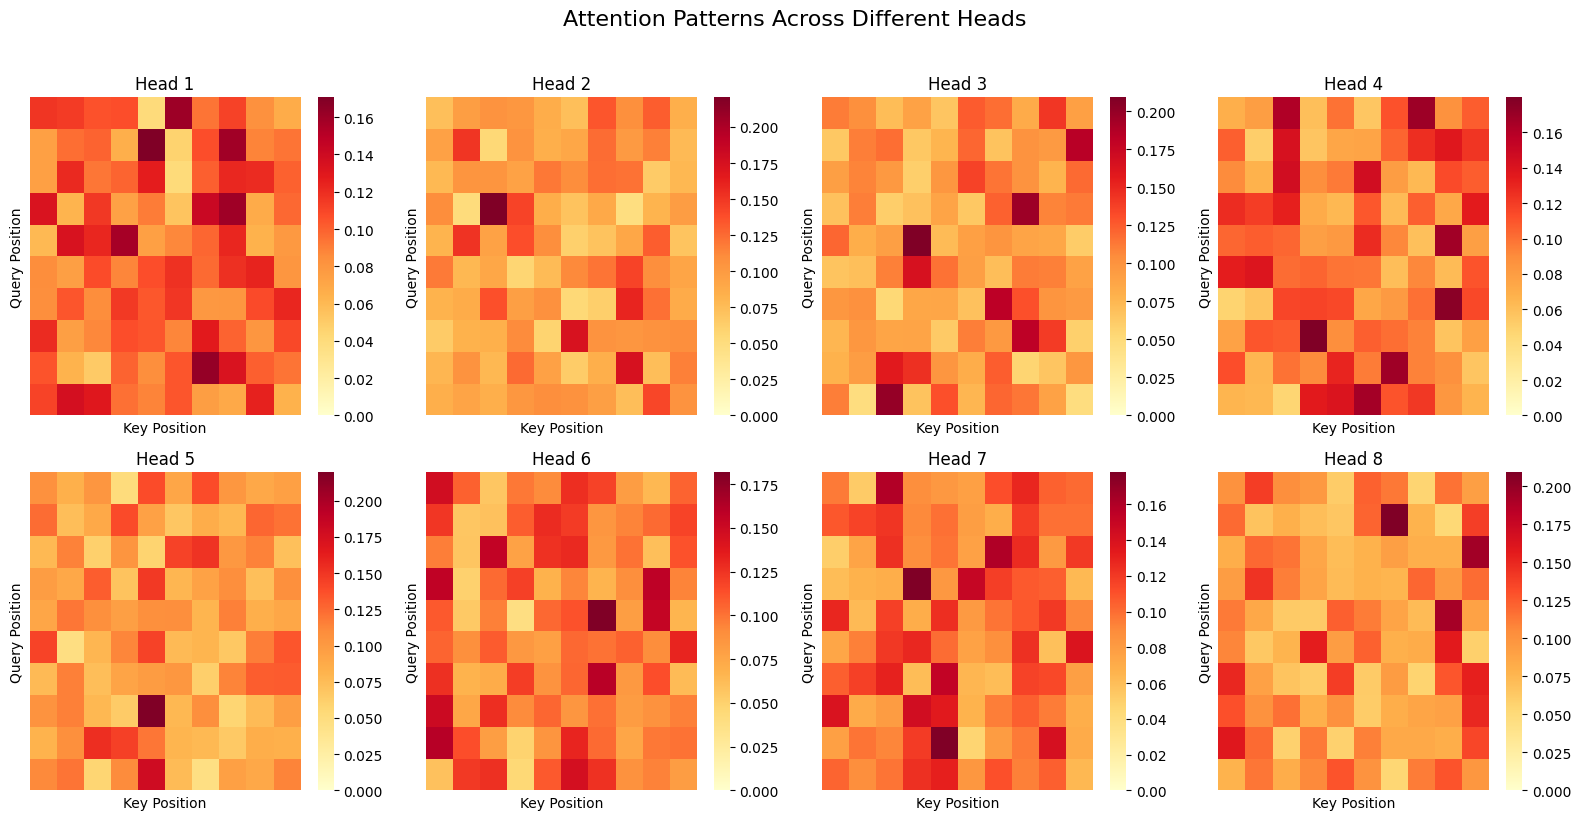


观察:
- 不同的头学习到不同的注意力模式
- 有些头可能关注局部信息
- 有些头可能关注全局信息
- 这种多样性使模型能够捕获不同类型的依赖关系


In [5]:
# 可视化第一个样本的所有头
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for head_idx in range(num_heads):
    attn = attn_weights[0, head_idx].detach().numpy()
    
    sns.heatmap(attn, ax=axes[head_idx], cmap='YlOrRd',
                xticklabels=False, yticklabels=False,
                cbar=True, vmin=0, vmax=attn.max())
    axes[head_idx].set_title(f'Head {head_idx + 1}')
    axes[head_idx].set_xlabel('Key Position')
    axes[head_idx].set_ylabel('Query Position')

plt.suptitle('Attention Patterns Across Different Heads', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("\n观察:")
print("- 不同的头学习到不同的注意力模式")
print("- 有些头可能关注局部信息")
print("- 有些头可能关注全局信息")
print("- 这种多样性使模型能够捕获不同类型的依赖关系")

## 4. 总结

### Multi-Head Attention 的关键点：

1. **多个表示子空间**: 每个头在不同的子空间中学习
2. **并行计算**: 所有头可以并行计算
3. **参数量**: 4 × d_model² (与头数无关)
4. **计算复杂度**: O(n² × d_model)

### 下一步：
- `03_grouped_query_attention.ipynb`: 学习 GQA，减少 KV 头数
- `04_kv_cache.ipynb`: 学习 KV Cache 优化推理速度